# 1. Problem Definition
Breast cancer is the most common cancer among women worldwide. In 2022, it led to approximately 670,000 deaths [1]. Hence, early diagnosis is critical especially since nearly half of cases occur without known risk factors. Medical imaging plays a key role in identifying cancer at its early stages.<br>In this project, I focus on using a deep learning model to classify breast medical images into healthy, non-cancerous and cancerous tumor caregories, in order to support faster and more accurate diagnosis.

[1] WHO. Breast Cancer Factsheet. https://www.who.int/news-room/fact-sheets/detail/breast-cancer

# 2. Resource Collection

This project uses the Breast Ultrasound Images Dataset [2] available on [Kaggle](https://www.kaggle.com/datasets/aryashah2k/breast-ultrasound-images-dataset/data).
Images are categorized into **three classes**:
- **Normal**: Healthy breast tissue with no abnormalities.  
- **Benign**: Non-cancerous findings (e.g., cysts, fibroadenomas) that may appear unusual but are not life-threatening.  
- **Malignant**: Cancerous tumors that may grow and spread, requiring urgent medical attention.

The `sample_data` folder includes one example image from each class.  

[2] Al-Dhabyani W, Gomaa M, Khaled H, Fahmy A. Dataset of breast ultrasound images. *Data in Brief*. 2020;28:104863. DOI: [10.1016/j.dib.2019.104863](https://doi.org/10.1016/j.dib.2019.104863)

# 3. Data Exploration

In this section, we explore the dataset to gain an initial understanding.<br>
First, we display two sample images from each class.<br>
Then, we analyze the class distribution by counting the number of images in each category.
### 3.1. Display sample images

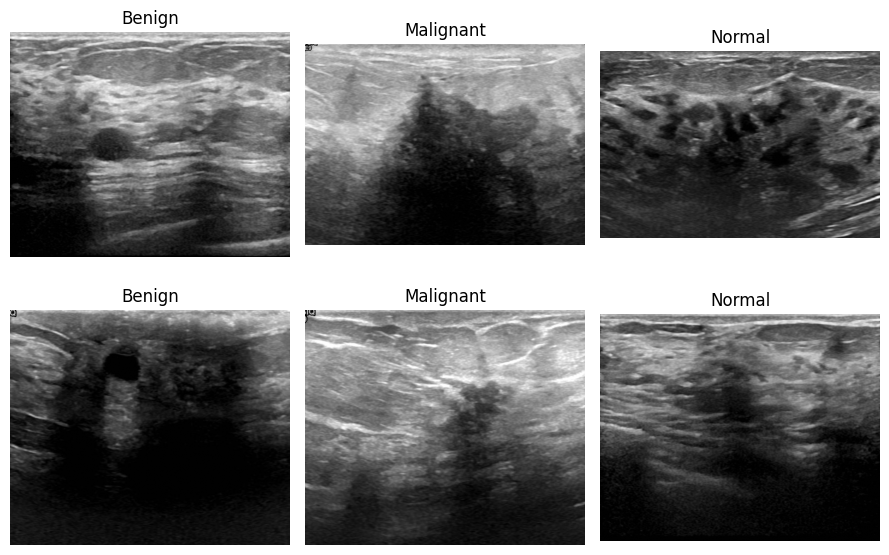

In [1]:
from pathlib import Path
from src.data_exploration import show_samples
dataset_path = Path("data/")
classes = ['benign', 'malignant', 'normal']

show_samples(dataset_path, classes)

### 3.2. Class distribution

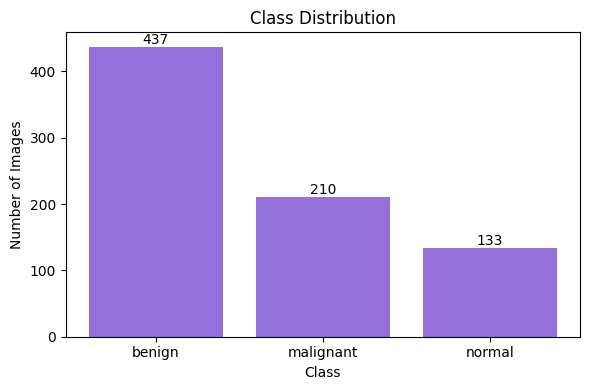

In [2]:
from src.data_exploration import plot_class_distribution

plot_class_distribution(dataset_path, classes)

# 4. Data Handling and Preprocessing

First, I resize all images to the same shape so they can be used in the model.

Since the dataset is small, I use 10-fold cross-validation instead of a fixed train/val split. This helps the model learn from more data and gives better performance estimates. I also set aside 15% of the data as a final test set, used only at the end.

The dataset is imbalanced, so to fix that, I use data augmentation on the smaller classes. Simple transformations like flipping, rotating, and brightness changes help create more training examples and make the model more balanced.

### 4.1. Resizing the images

In [3]:
from src.data_preprocessing import load_ultrasound_images, k_fold_augment
from sklearn.model_selection import train_test_split

IMAGE_SIZE = 224  # depends on the CNN model we choose
X, y = load_ultrasound_images(dataset_path, classes, IMAGE_SIZE)

2025-12-20 11:57:57.405656: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-20 11:57:57.405959: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-20 11:57:57.447764: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-20 11:57:58.495643: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computat

### 4.2. K folds with augmented data splitting

In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

augmenter = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True,
    fill_mode='nearest'
)

X_fold, X_test, y_fold, y_test = train_test_split(X, y, test_size=0.15,
                                                  stratify=y, random_state=42)
print(y_fold.shape)
folds = k_fold_augment(X_fold, y_fold, 5, augmenter)

(663,)

🔁 Fold 1/5
[0 1 2]
Class 0 original shape: (530, 224, 224, 3)
Class 0 augmented shape: (296, 224, 224, 3)
Class 1 original shape: (530, 224, 224, 3)
Class 1 augmented shape: (296, 224, 224, 3)
Class 2 original shape: (530, 224, 224, 3)
Class 2 augmented shape: (296, 224, 224, 3)

🔁 Fold 2/5
[0 1 2]
Class 0 original shape: (530, 224, 224, 3)
Class 0 augmented shape: (297, 224, 224, 3)
Class 1 original shape: (530, 224, 224, 3)
Class 1 augmented shape: (297, 224, 224, 3)
Class 2 original shape: (530, 224, 224, 3)
Class 2 augmented shape: (297, 224, 224, 3)

🔁 Fold 3/5
[0 1 2]
Class 0 original shape: (530, 224, 224, 3)
Class 0 augmented shape: (297, 224, 224, 3)
Class 1 original shape: (530, 224, 224, 3)
Class 1 augmented shape: (297, 224, 224, 3)
Class 2 original shape: (530, 224, 224, 3)
Class 2 augmented shape: (297, 224, 224, 3)

🔁 Fold 4/5
[0 1 2]
Class 0 original shape: (531, 224, 224, 3)
Class 0 augmented shape: (297, 224, 224, 3)
Class 1 original shape: (531, 224, 224, 3)


# 6. K-Fold Cross-Validation

To evaluate the model reliably on a small dataset, I use k-fold cross-validation.
The data is split into several folds. For each fold, the model is trained on the training split and evaluated on a different validation split.

For every fold:
- A new model is built and trained from scratch
- Performance is evaluated on the validation data
- Classification metrics and a confusion matrix are computed
## 6.1. Training

Training fold 1/5
(888, 224, 224, 3) (888,)
Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 26s 406ms/step - accuracy: 0.6802 - f1_m: 0.6944 - loss: 0.7924 - precision_m: 0.6892 - recall_m: 0.7008 - val_accuracy: 0.7293 - val_f1_m: 0.5765 - val_loss: 0.7207 - val_precision_m: 0.6327 - val_recall_m: 0.5370
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 31s 566ms/step - accuracy: 0.8874 - f1_m: 0.8885 - loss: 0.3066 - precision_m: 0.8750 - recall_m: 0.9054 - val_accuracy: 0.7820 - val_f1_m: 0.6550 - val_loss: 0.5578 - val_precision_m: 0.6595 - val_recall_m: 0.6554
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 28s 500ms/step - accuracy: 0.9516 - f1_m: 0.9473 - loss: 0.1542 - precision_m: 0.9407 - recall_m: 0.9545 - val_accuracy: 0.8120 - val_f1_m: 0.6555 - val_loss: 0.5035 - val_precision_m: 0.6572 - val_recall_m: 0.6570
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 30s 544ms/step - accuracy: 0.9640 - f1_m: 0.9609 - loss: 0.1065 - precision_m: 0.9482 - recall_m: 0.9753 - val_accuracy: 0.8346 - val_f1_m: 0.6861 - val_loss: 

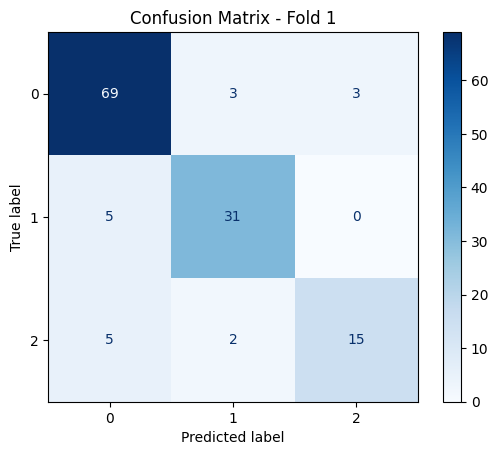

Training fold 2/5
(891, 224, 224, 3) (891,)
Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 33s 540ms/step - accuracy: 0.6835 - f1_m: 0.6966 - loss: 0.7846 - precision_m: 0.6939 - recall_m: 0.7009 - val_accuracy: 0.7293 - val_f1_m: 0.6456 - val_loss: 0.6431 - val_precision_m: 0.6948 - val_recall_m: 0.6072
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 27s 490ms/step - accuracy: 0.8967 - f1_m: 0.8960 - loss: 0.2737 - precision_m: 0.8841 - recall_m: 0.9110 - val_accuracy: 0.7744 - val_f1_m: 0.6906 - val_loss: 0.5021 - val_precision_m: 0.7303 - val_recall_m: 0.6591
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 27s 491ms/step - accuracy: 0.9473 - f1_m: 0.9487 - loss: 0.1579 - precision_m: 0.9408 - recall_m: 0.9576 - val_accuracy: 0.8271 - val_f1_m: 0.7977 - val_loss: 0.4161 - val_precision_m: 0.8046 - val_recall_m: 0.7931
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 27s 486ms/step - accuracy: 0.9787 - f1_m: 0.9786 - loss: 0.0845 - precision_m: 0.9747 - recall_m: 0.9829 - val_accuracy: 0.8346 - val_f1_m: 0.8005 - val_loss: 

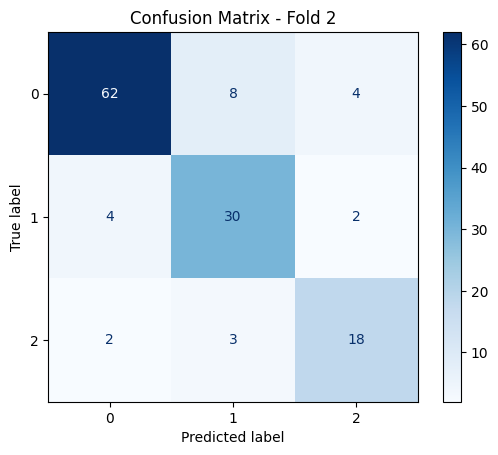

Training fold 3/5
(891, 224, 224, 3) (891,)
Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 35s 567ms/step - accuracy: 0.7059 - f1_m: 0.7107 - loss: 0.7020 - precision_m: 0.7050 - recall_m: 0.7177 - val_accuracy: 0.6316 - val_f1_m: 0.6444 - val_loss: 0.9065 - val_precision_m: 0.6256 - val_recall_m: 0.6692
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 32s 579ms/step - accuracy: 0.9181 - f1_m: 0.9227 - loss: 0.2522 - precision_m: 0.9178 - recall_m: 0.9282 - val_accuracy: 0.7218 - val_f1_m: 0.6925 - val_loss: 0.5858 - val_precision_m: 0.6563 - val_recall_m: 0.7369
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 32s 567ms/step - accuracy: 0.9506 - f1_m: 0.9511 - loss: 0.1436 - precision_m: 0.9419 - recall_m: 0.9610 - val_accuracy: 0.7368 - val_f1_m: 0.7131 - val_loss: 0.7983 - val_precision_m: 0.6789 - val_recall_m: 0.7561
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 31s 551ms/step - accuracy: 0.9719 - f1_m: 0.9718 - loss: 0.0891 - precision_m: 0.9645 - recall_m: 0.9796 - val_accuracy: 0.8195 - val_f1_m: 0.7694 - val_loss: 

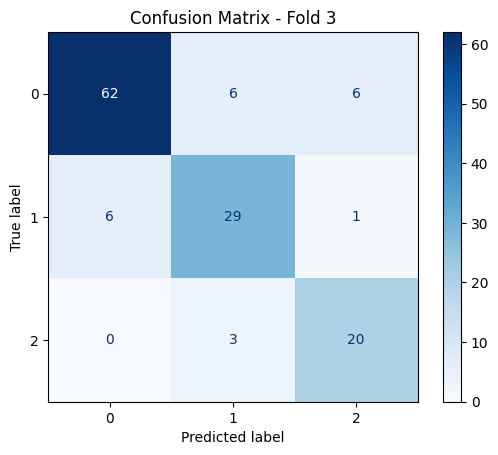

Training fold 4/5
(891, 224, 224, 3) (891,)
Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 32s 528ms/step - accuracy: 0.6734 - f1_m: 0.6915 - loss: 0.7815 - precision_m: 0.6933 - recall_m: 0.6914 - val_accuracy: 0.7500 - val_f1_m: 0.6533 - val_loss: 0.6138 - val_precision_m: 0.6442 - val_recall_m: 0.6698
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 30s 532ms/step - accuracy: 0.9068 - f1_m: 0.9101 - loss: 0.2623 - precision_m: 0.8982 - recall_m: 0.9237 - val_accuracy: 0.7652 - val_f1_m: 0.7329 - val_loss: 0.5141 - val_precision_m: 0.7301 - val_recall_m: 0.7405
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 25s 447ms/step - accuracy: 0.9574 - f1_m: 0.9562 - loss: 0.1317 - precision_m: 0.9509 - recall_m: 0.9618 - val_accuracy: 0.7803 - val_f1_m: 0.7504 - val_loss: 0.5064 - val_precision_m: 0.7634 - val_recall_m: 0.7412
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 25s 449ms/step - accuracy: 0.9731 - f1_m: 0.9680 - loss: 0.0908 - precision_m: 0.9617 - recall_m: 0.9751 - val_accuracy: 0.8258 - val_f1_m: 0.7871 - val_loss: 

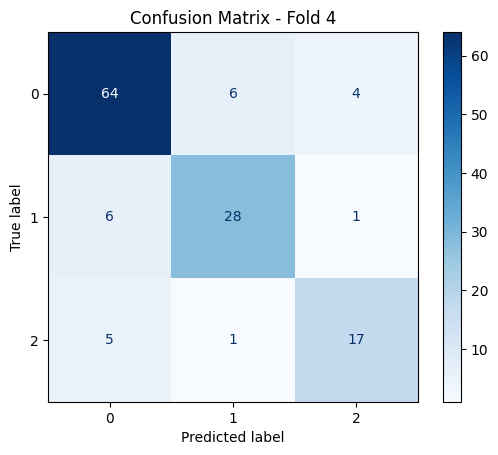

Training fold 5/5
(891, 224, 224, 3) (891,)
Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 28s 450ms/step - accuracy: 0.6857 - f1_m: 0.7001 - loss: 0.7412 - precision_m: 0.6968 - recall_m: 0.7084 - val_accuracy: 0.6667 - val_f1_m: 0.6449 - val_loss: 0.8111 - val_precision_m: 0.6459 - val_recall_m: 0.6517
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 25s 439ms/step - accuracy: 0.9012 - f1_m: 0.9055 - loss: 0.2682 - precision_m: 0.8997 - recall_m: 0.9121 - val_accuracy: 0.8333 - val_f1_m: 0.7528 - val_loss: 0.4641 - val_precision_m: 0.7606 - val_recall_m: 0.7476
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 24s 436ms/step - accuracy: 0.9439 - f1_m: 0.9452 - loss: 0.1558 - precision_m: 0.9367 - recall_m: 0.9545 - val_accuracy: 0.8030 - val_f1_m: 0.7134 - val_loss: 0.4480 - val_precision_m: 0.7365 - val_recall_m: 0.6988
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 25s 439ms/step - accuracy: 0.9719 - f1_m: 0.9670 - loss: 0.1005 - precision_m: 0.9610 - recall_m: 0.9738 - val_accuracy: 0.8561 - val_f1_m: 0.7634 - val_loss: 

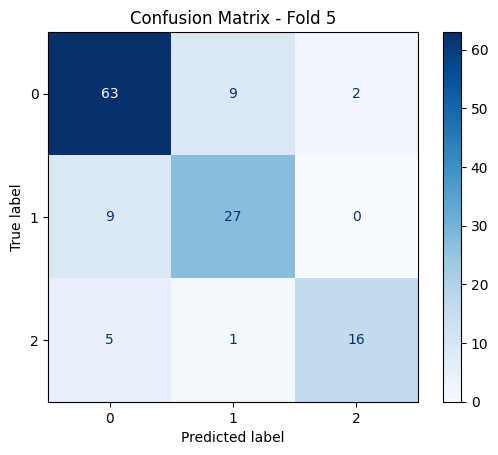

In [7]:
from src.model_development import build_model
import keras as K
import numpy as np
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

num_folds = len(folds)
val_scores = []

for fold_idx, (X_train, y_train, X_val, y_val) in enumerate(folds, start=1):
    print(f"Training fold {fold_idx}/{len(folds)}")
    print(X_train.shape, y_train.shape)

    # Ensure correct dtype
    X_train = X_train.astype('float32')
    X_val = X_val.astype('float32')

    # Build model for this fold
    model = build_model()

    # Train model
    model.fit(
        X_train, y_train,
        batch_size=16,
        epochs=20,
        validation_data=(X_val, y_val)
    )
        # Evaluate on validation data
    results = model.evaluate(X_val, y_val)
    val_scores.append(results)
    print(f"Results for fold {fold_idx} : {results}")

    # Predictions
    y_pred_probs = model.predict(X_val)
    y_pred = y_pred_probs.argmax(axis=1)

    # Classification report
    print(classification_report(y_val, y_pred, digits=4))

    # Confusion Matrix
    y_pred_classes = np.argmax(y_pred_probs, axis=1)
    cm = confusion_matrix(y_val, y_pred_classes)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix - Fold {fold_idx}")
    plt.show()

## 6.2. Cross-Validation Results
After training the model using k-fold cross-validation, the performance is aggregated across all folds.
Reporting the mean and standard deviation allows evaluating both performance and stability of the model across different data splits.

📊 Cross-Validation Performance Summary

loss                : 0.7369 ± 0.1137
compile_metrics     : 0.8310 ± 0.0199


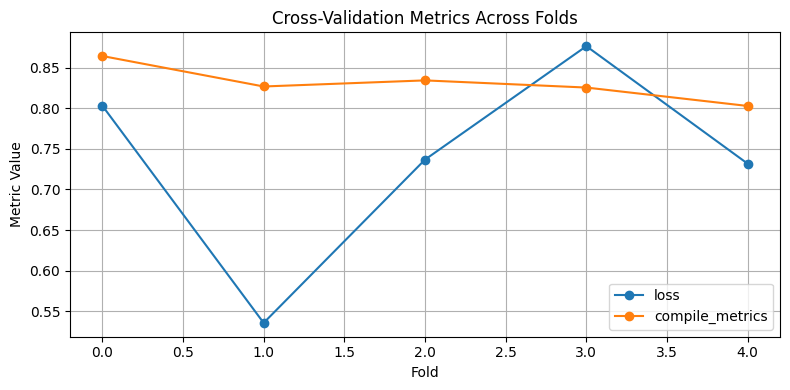

In [8]:
from src.evaluation_metrics import summarize_cv_results, plot_cv_metrics
summarize_cv_results(val_scores, model.metrics_names)
plot_cv_metrics(val_scores, model.metrics_names)

In [9]:
val_scores = np.array(val_scores)
print("val_scores shape:", val_scores.shape)
print("Example fold output:", val_scores[0])

val_scores shape: (5, 5)
Example fold output: [0.8034212  0.86466163 0.81877774 0.784127   0.79964304]


## 6.3. Discussion
The cross-validation results show consistent performance across folds, indicating good generalization despite the limited dataset size.

Balanced accuracy and macro-averaged metrics were used to account for class imbalance, which is critical in medical imaging tasks.

The model demonstrates particularly strong performance on benign and normal cases, while malignant detection remains acceptable but highlights the importance of recall-focused evaluation.

# 7. Model Training and Final Evaluation
## 7.1. Model Training

We reuse the same architecture and hyperparameters validated during cross-validation.

In [ ]:
X_train = X_fold.astype("float32")
y_train = y_fold.astype("float32")

model = build_model()
model.fit(
    X_train,
    y_train,
    batch_size=16,
    epochs=20,
)


Epoch 1/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 18s 335ms/step - accuracy: 0.5566 - f1_m: 0.5478 - loss: 1.0898 - precision_m: 0.5401 - recall_m: 0.5659
Epoch 2/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 18s 423ms/step - accuracy: 0.8431 - f1_m: 0.8145 - loss: 0.3940 - precision_m: 0.8049 - recall_m: 0.8290
Epoch 3/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 19s 441ms/step - accuracy: 0.9110 - f1_m: 0.8754 - loss: 0.2564 - precision_m: 0.8677 - recall_m: 0.8853
Epoch 4/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 18s 436ms/step - accuracy: 0.9472 - f1_m: 0.9313 - loss: 0.1611 - precision_m: 0.9268 - recall_m: 0.9382
Epoch 5/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 21s 445ms/step - accuracy: 0.9744 - f1_m: 0.9441 - loss: 0.0994 - precision_m: 0.9419 - recall_m: 0.9471
Epoch 6/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 20s 469ms/step - accuracy: 0.9894 - f1_m: 0.9818 - loss: 0.0608 - precision_m: 0.9815 - recall_m: 0.9824
Epoch 7/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 18s 436ms/step - accuracy: 0.9879 - f1_m: 0.9562 - loss: 0.0557 - precision_m: 0.9537 - recall_m: 0.9592

In [14]:
test_metrics = model.evaluate(
    X_test.astype("float32"),
    y_test,
    verbose=0
)

## 7.2. Test Set Evaluation
### 7.2.1 Quantitative Metrics

In [15]:
from sklearn.metrics import (
    classification_report,
    balanced_accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Predictions
y_probs = model.predict(X_test, verbose=0)
y_pred = y_probs.argmax(axis=1)

# Classification report
print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Benign", "Malignant", "Normal"],
    digits=4
))

# Additional metrics
bal_acc = balanced_accuracy_score(y_test, y_pred)
print(f"Balanced Accuracy: {bal_acc:.4f}")

Classification Report:
              precision    recall  f1-score   support

      Benign     0.9014    0.9697    0.9343        66
   Malignant     0.8333    0.8065    0.8197        31
      Normal     0.9375    0.7500    0.8333        20

    accuracy                         0.8889       117
   macro avg     0.8907    0.8420    0.8624       117
weighted avg     0.8895    0.8889    0.8867       117

Balanced Accuracy: 0.8420


### 7.2.2. Confusion Matrix

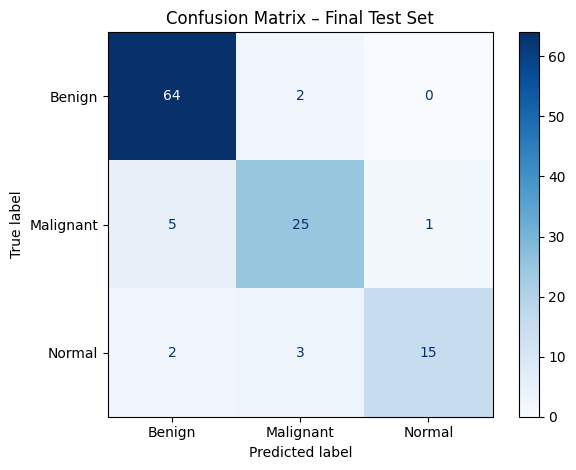

In [16]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malignant", "Normal"]
)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix – Final Test Set")
plt.tight_layout()
plt.show()

In [17]:
from sklearn.metrics import (
    classification_report,
    balanced_accuracy_score,
    precision_recall_fscore_support
)

print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Benign", "Malignant", "Normal"],
        digits=4
    )
)

bal_acc = balanced_accuracy_score(y_test, y_pred)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="macro"
)

print("\nFinal Test Metrics:")
print(f"Balanced Accuracy : {bal_acc:.4f}")
print(f"Macro Precision   : {precision:.4f}")
print(f"Macro Recall      : {recall:.4f}")
print(f"Macro F1-score    : {f1:.4f}")


Classification Report:
              precision    recall  f1-score   support

      Benign     0.9014    0.9697    0.9343        66
   Malignant     0.8333    0.8065    0.8197        31
      Normal     0.9375    0.7500    0.8333        20

    accuracy                         0.8889       117
   macro avg     0.8907    0.8420    0.8624       117
weighted avg     0.8895    0.8889    0.8867       117


Final Test Metrics:
Balanced Accuracy : 0.8420
Macro Precision   : 0.8907
Macro Recall      : 0.8420
Macro F1-score    : 0.8624
